# Synthetic Difference-in-Differences (SDID) Example

This notebook provides a complete walkthrough of the **Synthetic Difference-in-Differences (SDID)** method using the `sdid` package. 

## What is SDID?
SDID (Arkhangelsky et al., 2021) is a causal inference method that combines the benefits of:
1. **Difference-in-Differences (DiD)**: Interpretable, handles time-invariant unobserved heterogeneity.
2. **Synthetic Control Method (SCM)**: Handles non-parallel trends by re-weighting control units.

## Workflow
1. **Simulate Data**: Create a dataset with non-parallel trends (where standard DiD fails).
2. **Naïve Analysis**: Show that standard DiD produces biased estimates.
3. **SDID Analysis**: Apply SDID to recover the true treatment effect.
4. **Diagnostics**: Visualize the "Synthetic Control" unit and weights.
5. **Inference**: Calculate standard errors and confidence intervals.

In [10]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sdid import SyntheticDiffInDiff

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Simulate Data (Latent Factor Model)

We generate data where the outcome depends on a **time factor** ($F_t$) and **unit-specific loadings** ($\lambda_i$). 
$$ Y_{it} = \lambda_i F_t + \tau D_{it} + \epsilon_{it} $$

*   **Control Units**: Have random loadings $\lambda_i \approx 1.0$.
*   **Treated Unit**: Has a higher loading $\lambda_{treat} = 1.8$, meaning it reacts more strongly to the time trend (e.g., grows faster naturally).
*   **Violation**: Because $\lambda_{treat} \neq E[\lambda_{control}]$, the parallel trends assumption holds only if we re-weight the controls.

In [11]:
# --- Configuration ---
N_CONTROL = 50
N_TREATED = 1
YEARS = sorted(range(2000, 2021))
TREATMENT_YEAR = 2015
TRUE_EFFECT = 10.0

# --- Data Generation ---
n_units = N_CONTROL + N_TREATED
units = [f"Unit_{i:02d}" for i in range(n_units)]
treated_unit = units[-1] # The last unit is treated

# 1. Common Time Factor (Global Trend)
# Linear trend + Random Walk
time_factor = np.arange(len(YEARS)) + np.cumsum(np.random.normal(0, 0.5, len(YEARS)))

# 2. Unit Loadings (Sensitivities)
unit_loadings = np.random.uniform(0.5, 1.5, n_units)
# MAKE PARALLEL TRENDS FAIL: Treated unit has steeper trend
unit_loadings[-1] = 1.8

# 3. Build DataFrame
data = []
for i, unit in enumerate(units):
    is_treated = (unit == treated_unit)
    loading = unit_loadings[i]

    for t_idx, year in enumerate(YEARS):
        is_post = year >= TREATMENT_YEAR

        # Base Outcome
        outcome = loading * time_factor[t_idx] + np.random.normal(0, 2.0)

        # Add Treatment Effect
        if is_treated and is_post:
            outcome += TRUE_EFFECT

        data.append({
            'unit': unit,
            'year': year,
            'outcome': outcome,
            'treated': is_treated,
            'post': is_post
        })

df = pd.DataFrame(data)

print(f"Data Shape: {df.shape}")
print(f"Treated Unit: {treated_unit}")
df.head()

Data Shape: (1071, 5)
Treated Unit: Unit_50


,unit,year,outcome,treated,post
0,Unit_00,2000,-0.277784,False,False
1,Unit_00,2001,0.410741,False,False
2,Unit_00,2002,0.504377,False,False
3,Unit_00,2003,-0.032489,False,False
4,Unit_00,2004,5.800870,False,False


### Visualize Raw Data
Notice the **red line** (Treated) is diverging from the **gray lines** (Controls) even before 2015. This confirms that parallel trends do not hold for the simple average.

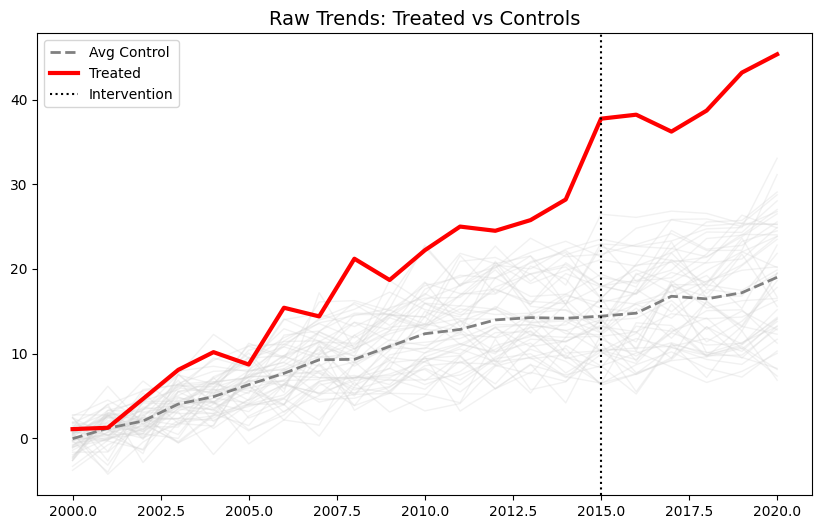

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all control units
for unit in df[~df['treated']]['unit'].unique():
    unit_data = df[df['unit'] == unit]
    ax.plot(unit_data['year'], unit_data['outcome'], color='lightgray', alpha=0.3, linewidth=1)

# Plot average control
avg_control = df[~df['treated']].groupby('year')['outcome'].mean()
ax.plot(avg_control.index, avg_control.values,
        color='gray', linestyle='--', linewidth=2, label='Avg Control')

# Plot treated unit
treated_data = df[df['treated']]
ax.plot(treated_data['year'], treated_data['outcome'], color='red', linewidth=3, label='Treated')

ax.axvline(x=TREATMENT_YEAR, color='black', linestyle=':', label='Intervention')
ax.set_title("Raw Trends: Treated vs Controls", fontsize=14)
ax.legend()
plt.show()

## 2. Naïve Analysis (Standard DiD)
Standard DiD assumes that without treatment, the treated unit would have evolved like the average control unit.
$$ \hat{\tau}_{DiD} = (\bar{y}_{post}^{tr} - \bar{y}_{pre}^{tr}) - (\bar{y}_{post}^{co} - \bar{y}_{pre}^{co}) $$

In [13]:
# Calculate DiD manually
y_tr_post = df[df['treated'] & df['post']]['outcome'].mean()
y_tr_pre = df[df['treated'] & ~df['post']]['outcome'].mean()
y_co_post = df[~df['treated'] & df['post']]['outcome'].mean()
y_co_pre = df[~df['treated'] & ~df['post']]['outcome'].mean()

did_estimate = (y_tr_post - y_tr_pre) - (y_co_post - y_co_pre)

print(f"True Effect:       {TRUE_EFFECT:.2f}")
print(f"Standard DiD Est:  {did_estimate:.2f}")
print(f"Bias:              {did_estimate - TRUE_EFFECT:.2f}")

True Effect:       10.00
Standard DiD Est:  16.40
Bias:              6.40


> **Result**: The standard DiD estimate is significantly biased (overestimated) because it attributes the naturally faster growth of the treated unit to the treatment.

## 3. SDID Analysis
SDID fixes this by:
1. Finding **Unit Weights** ($\omega_i$) to make the weighted control average match the treated unit's pre-treatment trend.
2. Finding **Time Weights** ($\lambda_t$) to balance pre/post periods.
3. Running a weighted Two-Way Fixed Effects regression.

In [14]:
sdid = SyntheticDiffInDiff(
    data=df,
    outcome_col='outcome',
    times_col='year',
    units_col='unit',
    treat_col='treated',
    post_col='post'
)

# Fit the model
sdid_effect = sdid.fit(verbose=True)

INFO:sdid.core:Data validated: 1 treated units, 50 controls, 15 pre-periods, 6 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Unit regularization: 4.4301
(CVXPY) Dec 26 09:55:13 AM: Your problem has 51 variables, 0 constraints, and 0 parameters.
(CVXPY) Dec 26 09:55:13 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Dec 26 09:55:13 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Dec 26 09:55:13 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Dec 26 09:55:13 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Dec 26 09:55:13 AM: Compiling problem (target solver=OSQP).
(CVXPY) Dec 26 09:55:13 AM: Reduction chain: CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> OSQP
(CVXPY) Dec 26 09:55:13 AM: Applying reduction CvxAttr2Constr
(CVXPY) Dec 26 09:5

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 66, constraints m = 65
          nnz(P) + nnz(A) = 895
settings: algebra = Built-in,
          OSQPInt = 4

In [15]:
print("="*40)
print(f"True Effect:       {TRUE_EFFECT:.2f}")
print(f"SDID Estimate:     {sdid_effect:.2f}")
print(f"Error:             {abs(sdid_effect - TRUE_EFFECT):.2f}")
print("="*40)

True Effect:       10.00
SDID Estimate:     14.41
Error:             4.41


## 4. Diagnostics: The Synthetic Control Curve
We can verify SDID's performance by plotting the constructed "Synthetic Control".
If SDID worked, the **blue dashed line** (Synthetic Control) should track the **red solid line** (Treated) perfectly *before* the intervention.

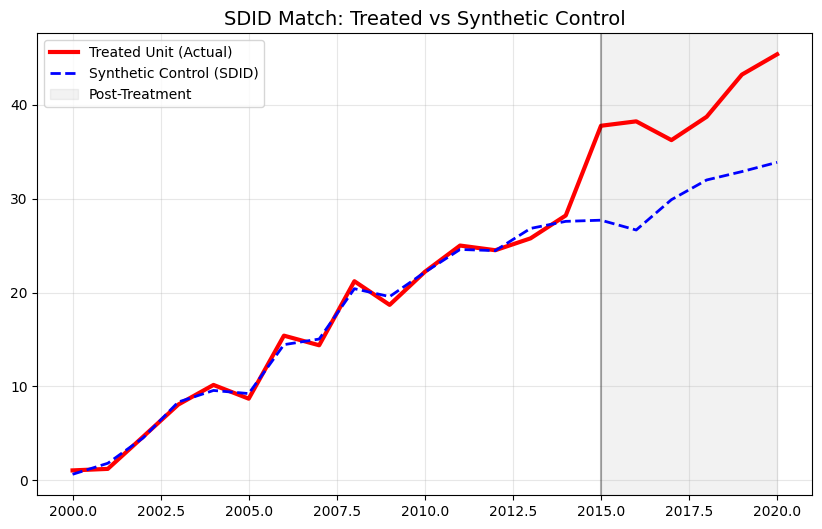

In [16]:
# Extract Weights
weights = sdid.unit_weights

# Calculate Synthetic Control Outcome (Weighted Average)
control_wide = df[~df['treated']].pivot(index='year', columns='unit', values='outcome')
valid_controls = weights.index.intersection(control_wide.columns)
synthetic_trend = control_wide[valid_controls].dot(weights[valid_controls])

# Adjust Level (Intercept)
# SDID matches trends, not levels, so we align them in the pre-period
treated_outcome = df[df['treated']].set_index('year')['outcome']
pre_years = [y for y in YEARS if y < TREATMENT_YEAR]
diff_mean = treated_outcome.loc[pre_years].mean() - synthetic_trend.loc[pre_years].mean()
synthetic_control = synthetic_trend + diff_mean

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(treated_outcome.index, treated_outcome.values,
        color='red', linewidth=3, label='Treated Unit (Actual)')

ax.plot(synthetic_control.index, synthetic_control.values,
        color='blue', linestyle='--', linewidth=2, label='Synthetic Control (SDID)')

ax.axvline(x=TREATMENT_YEAR, color='black', alpha=0.3)
ax.axvspan(TREATMENT_YEAR, max(YEARS), color='gray', alpha=0.1, label='Post-Treatment')

ax.set_title("SDID Match: Treated vs Synthetic Control", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 5. Inference (Placebo Bootstrap)
We use a placebo bootstrap procedure to estimate standard errors and confidence intervals. This involves re-running the analysis on control units as if they were treated.

In [17]:
print("Running bootstrap inference (n=50)...")

sdid.estimate_se(n_bootstrap=50)
print(sdid.summary())

INFO:sdid.core:Estimating standard error with 50 bootstrap samples...
INFO:sdid.core:Data validated: 2 treated units, 49 controls, 15 pre-periods, 6 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Unit regularization: 5.2853
INFO:sdid.core:Unit weights estimated: 14 units with non-zero weights
INFO:sdid.core:Unit intercept: 1.0935
INFO:sdid.core:Estimating time weights...
INFO:sdid.core:Time regularization: 1.7931
INFO:sdid.core:Time weights estimated: 0 periods with non-zero weights
INFO:sdid.core:Time intercept: 0.0000
INFO:sdid.core:Merging weights with data...
INFO:sdid.core:Weights merged successfully
INFO:sdid.core:Running weighted regression...


Running bootstrap inference (n=50)...


INFO:sdid.core:Treatment effect: 9.1516
INFO:sdid.core:SDID analysis complete!
INFO:sdid.core:Data validated: 2 treated units, 49 controls, 15 pre-periods, 6 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Unit regularization: 5.2453
INFO:sdid.core:Unit weights estimated: 19 units with non-zero weights
INFO:sdid.core:Unit intercept: 0.3318
INFO:sdid.core:Estimating time weights...
INFO:sdid.core:Time regularization: 1.7931
INFO:sdid.core:Time weights estimated: 0 periods with non-zero weights
INFO:sdid.core:Time intercept: 0.0000
INFO:sdid.core:Merging weights with data...
INFO:sdid.core:Weights merged successfully
INFO:sdid.core:Running weighted regression...
INFO:sdid.core:Treatment effect: 8.1411
INFO:sdid.core:SDID analysis complete!
INFO:sdid.core:Data validated: 2 treated units, 49 controls, 15 pre-periods, 6 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core

Synthetic Difference-in-Differences Results
Treatment Effect (ATT): 14.4076
Standard Error:        4.5440
t-statistic:           3.1707
p-value:               0.0015
Control units used:    11
Time periods used:     0


INFO:sdid.core:Creating event study plot...
INFO:sdid.core:Running event study for 21 time periods...
INFO:sdid.core:Data validated: 1 treated units, 50 controls, 15 pre-periods, 1 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Unit regularization: 2.8306
INFO:sdid.core:Unit weights estimated: 11 units with non-zero weights
INFO:sdid.core:Unit intercept: 1.1356
INFO:sdid.core:Estimating time weights...
INFO:sdid.core:Time regularization: 1.7931
INFO:sdid.core:Time weights estimated: 0 periods with non-zero weights
INFO:sdid.core:Time intercept: 0.0000
INFO:sdid.core:Merging weights with data...
INFO:sdid.core:Weights merged successfully
INFO:sdid.core:Running weighted regression...
INFO:sdid.core:Treatment effect: 13.7747
INFO:sdid.core:SDID analysis complete!
INFO:sdid.core:Data validated: 1 treated units, 50 controls, 15 pre-periods, 1 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit w

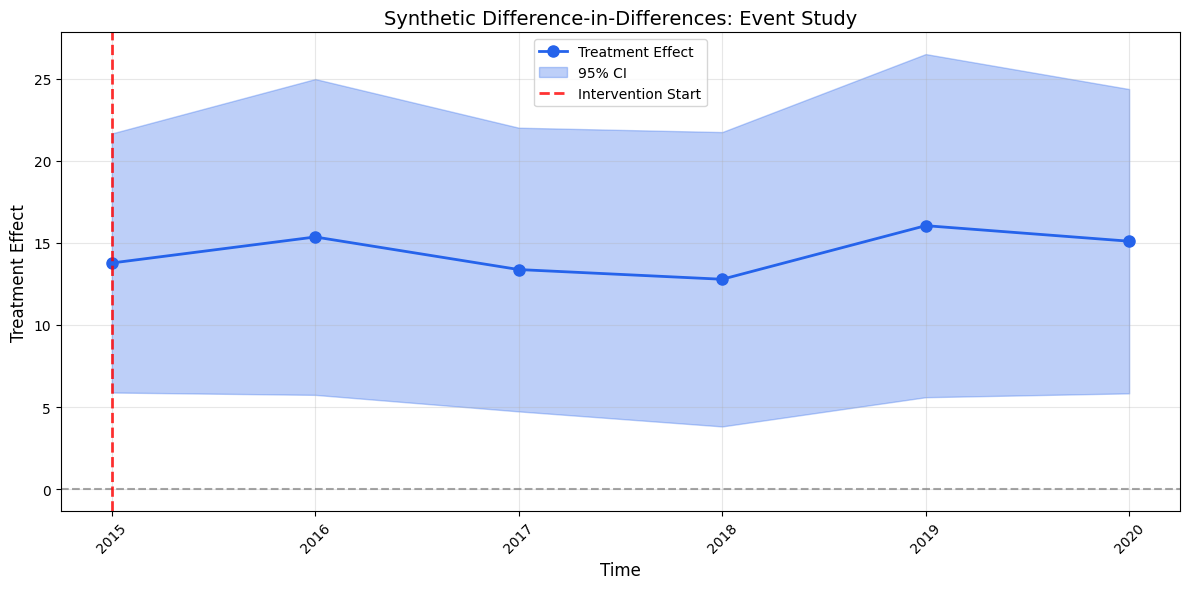

In [18]:
# Event Study Plot
fig = sdid.plot_event_study(
    times=YEARS,
    n_bootstrap=50,
    confidence_level=0.95
)
plt.show()